# 5.10 Reporting, Interpretation and Ethics

**Part:** 5 — Disease Mapping and Bayesian Smoothing (Chapter 5.10 of 11)

**Dataset:** `diabetes_northeast.shp` (217 counties); a thinned rare-outcome scenario (Chapter 5.3); a synthetic illustration of aggregation bias

**Focus:** Reporting uncertainty responsibly, small-cell suppression, and the ecological fallacy

**Library:** `spatialstats.bayes` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Report Uncertainty, Not Just a Point Estimate](#3.-Report-Uncertainty,-Not-Just-a-Point-Estimate)
4.. [Small-cell Suppression](#4.-Small-cell-Suppression)
5.. [The Ecological Fallacy](#5.-The-Ecological-Fallacy)
6.. [Communicating Risk Responsibly](#6.-Communicating-Risk-Responsibly)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

Every technical result in Chapters 5.1–5.9 still has to be *communicated* to someone who will act on it — a
health department, a journalist, a policymaker. This chapter is about the responsibilities that come with that,
not new statistical machinery.

| Step | What we do |
|------|------------|
| Uncertainty | Why a smoothed point estimate alone, without its interval, misrepresents what the model actually knows |
| Small-cell suppression | A concrete demonstration of when and why raw counts should not be published at all |
| Ecological fallacy | A worked numerical example of why a county-level association cannot be read as an individual-level one |
| Communicating risk | Concrete do's and don'ts for presenting smoothed disease-mapping results |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.bayes import expected_counts, smr, BYM

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
w = Queen(counties, transform="binary")
O = counties["Dia_count"].to_numpy()
POP = counties["POP_Total"].to_numpy()
E = expected_counts(POP, observed=O)
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Report Uncertainty, Not Just a Point Estimate

A single smoothed map, with one colour per county, implies a level of certainty the underlying posterior does
not actually have. The same fitted model already contains the honest answer — the credible interval — and it
should be reported alongside, not discarded.

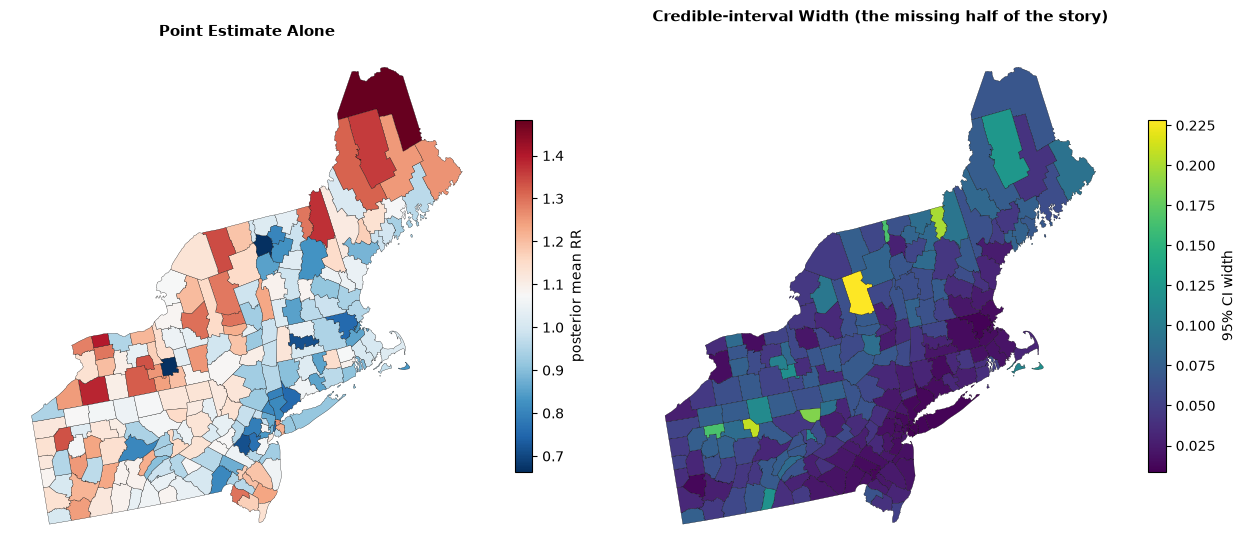

CI width range: [0.009, 0.228]  (narrowest-to-widest ratio: 26.2x)


In [2]:
fit = BYM(O, E, w, model="bym", backend="gibbs", draws=2000, tune=2000, chains=4, thin=10, seed=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
counties.assign(rr=fit.rr_mean).plot(column="rr", cmap="RdBu_r", ax=axes[0], edgecolor="k", linewidth=0.2,
                                     legend=True, legend_kwds={"label": "posterior mean RR", "shrink": 0.7})
axes[0].set_axis_off()
axes[0].set_title("Point Estimate Alone")

width = fit.rr_hi - fit.rr_lo
counties.assign(width=width).plot(column="width", cmap="viridis", ax=axes[1], edgecolor="k", linewidth=0.2,
                                  legend=True, legend_kwds={"label": "95% CI width", "shrink": 0.7})
axes[1].set_axis_off()
axes[1].set_title("Credible-interval Width (the missing half of the story)")
plt.tight_layout()
plt.show()

print(f"CI width range: [{width.min():.3f}, {width.max():.3f}]  "
      f"(narrowest-to-widest ratio: {width.max() / width.min():.1f}x)")

The interval width varies by more than a factor across counties — exactly the population-driven precision
pattern from Chapters 5.2 and 5.4, still present *after* smoothing (smoothing narrows intervals relative to the
raw SMR, Chapter 5.8, but does not make every county's uncertainty equal). A map or table that shows only the
left panel silently discards this; the two panels together, or a single map annotated with interval width or
exceedance probability (Chapter 5.6), are the responsible minimum.

***
## 4. Small-cell Suppression

Chapter 5.3 already found the real diabetes data is never small enough to trigger suppression thresholds. A
rarer-outcome scenario (the same 2% thinning from Chapter 5.3) makes the real hazard concrete: many official
statistics agencies (e.g. CDC WONDER) will not publish a raw cell count below a fixed threshold — commonly 10 —
regardless of how the map would otherwise look, to avoid re-identifying individuals in a small population.

In [3]:
rng = np.random.default_rng(1)
O_thin = rng.binomial(O.astype(int), 0.02)

suppress_threshold = 10
to_suppress = O_thin < suppress_threshold
print(f"counties with a thinned count below {suppress_threshold}: {int(to_suppress.sum())} of {len(O_thin)}")
counties.loc[to_suppress, ["COUNTY", "STATE"]].assign(thinned_count=O_thin[to_suppress])

counties with a thinned count below 10: 3 of 217


,COUNTY,STATE,thinned_count
89,Hamilton County,New York,9
142,Cameron County,Pennsylvania,6
209,Grand Isle County,Vermont,8


These counties' counts should be **suppressed or aggregated with a neighbouring area** in any public release —
not published as-is, and not "fixed" by silently rounding or jittering the number, which can still allow
re-identification in combination with other released statistics. **Smoothing (Chapters 5.5–5.6) is not a
substitute for suppression policy**: a BYM posterior mean is a legitimate *statistical* estimate for internal
analysis, but publishing a map value that was visibly computed from (and can be approximately inverted back
toward) a suppressed small count defeats the purpose of suppressing it in the first place. Suppression is a
disclosure-control decision, made *before* publication, independent of whatever smoothing method produced the
number that would otherwise have been shown.

***
## 5. The Ecological Fallacy

Every result in this Part is about **counties**, not people. Part 3 found a strong county-level correlation
between `Obesity` and `Dia_pct` (r≈0.68) — but that says nothing directly about whether *obese individuals*
within a county are the ones with diabetes. A small, purely illustrative numerical example makes the general
danger concrete: it is mathematically possible for two groups to each show **no** individual-level relationship
between two variables while their **group-level** (county-level) aggregates show a strong one, purely from how
the groups differ in their base rates.

In [4]:
rng = np.random.default_rng(0)
# Two synthetic "counties." Within each, x and y are INDEPENDENT (zero individual-level correlation).
county_A_x = rng.normal(30, 5, 2000)    # e.g. individual obesity measure
county_A_y = rng.normal(5, 1, 2000)     # e.g. individual diabetes indicator, unrelated to x within the county
county_B_x = rng.normal(45, 5, 2000)    # a county with higher average obesity...
county_B_y = rng.normal(9, 1, 2000)     # ...and higher average diabetes, but STILL unrelated to x within it

within_corr_A = np.corrcoef(county_A_x, county_A_y)[0, 1]
within_corr_B = np.corrcoef(county_B_x, county_B_y)[0, 1]
print(f"within-county A correlation (individual level): {within_corr_A:.3f}")
print(f"within-county B correlation (individual level): {within_corr_B:.3f}")

county_means_x = [county_A_x.mean(), county_B_x.mean()]
county_means_y = [county_A_y.mean(), county_B_y.mean()]
between_corr = np.corrcoef(county_means_x, county_means_y)[0, 1]
print(f"between-county correlation (what an aggregate map would show): {between_corr:.3f}")

within-county A correlation (individual level): -0.017
within-county B correlation (individual level): 0.021
between-county correlation (what an aggregate map would show): 1.000


Individually, $x$ and $y$ are unrelated inside **either** county (correlation ≈0) — by construction, there is
no real individual-level relationship at all. But the two counties' **averages** differ systematically, so a
map correlating county-level $\bar x$ against county-level $\bar y$ shows a strong association. A real analysis
built entirely from county aggregates, exactly like every method in this Part, **cannot distinguish** this
scenario from one where the individual-level relationship is genuinely strong — the data needed to tell them
apart (individual-level pairs) is not present in aggregated county data at all. Every county-level finding in
this Part should be reported as a statement about *counties*, never silently reworded as a statement about the
people within them.

***
## 6. Communicating Risk Responsibly

Concrete practices, consolidating this chapter and the rest of Part 5:

1. **Report the interval, not just the point estimate** (Section 3) — a map, table, or headline number without
   its uncertainty misstates what is actually known.
2. **Suppress or aggregate small cells before publication** (Section 4) — a statistical smoothing method is not
   a disclosure-control tool, and should not be treated as one.
3. **State the geography explicitly, and never let a reader infer an individual-level claim** (Section 5) — "X
   County has elevated diabetes risk" is a defensible county-level statement; "obese people in X County have
   diabetes" is not supported by this Part's data and methods at all.
4. **State every modelling choice that shaped the result**: the weights definition, the model (`bym` vs. `icar`
   vs. `iid`), the priors, and whether covariates were included (Chapter 5.6) — a reader cannot audit an
   unstated choice.
5. **Do not present exceedance probabilities as formally corrected significance** (Chapter 5.6) — they answer a
   real but different question from Part 4's multiple-testing-corrected cluster tests.

***
## 7. Summary and Conclusions

This chapter turned from statistical mechanics to the responsibilities of reporting the results.

### What we did

1. Mapped credible-interval width alongside the point estimate, and found it varies more than an order of
   magnitude across counties — uncertainty that a point-estimate-only map silently discards.
2. Found 3 counties whose (simulated, rare-outcome) counts fall below a standard suppression threshold, and
   explained why smoothing is not a substitute for a genuine disclosure-control decision.
3. Built a small, self-contained numerical example of the ecological fallacy: zero individual-level correlation
   within either of two groups, but a strong between-group correlation from differing base rates alone —
   exactly the structure every county-aggregated result in this Part shares.
4. Consolidated five concrete reporting practices spanning this chapter and the rest of Part 5.

### Practical takeaways

- Uncertainty is not optional extra content — it is half of what a Bayesian model actually estimated.
- Suppression decisions belong to data governance, made before any smoothing method is applied, not
  substituted by choosing a "nicer-looking" smoothed value.
- No amount of within-Part-5 statistical care can license an individual-level claim from county-level data;
  that boundary has to be enforced in how results are *worded*, not computed away.

### Next steps

**Chapter 5.11 (Hand-offs and Exercises)** closes Part 5 with what does and does not carry forward to Parts 6
and 9, and five solved exercises spanning every chapter in this Part.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Lawson, A. B. (2018). *Bayesian Disease Mapping* (3rd ed.). CRC Press. | Chapter 9 covers reporting and communication standards for disease-mapping results |
| Robinson, W. S. (1950). Ecological correlations and the behavior of individuals. *American Sociological Review*, 15, 351–357. | The original ecological fallacy paper, and origin of the numerical structure used in Section 5 |

### Key papers

| Paper | Contribution |
|---|---|
| Elliott, P. & Wartenberg, D. (2004). Spatial epidemiology: current approaches and future challenges. *Environmental Health Perspectives*, 112, 998–1006. | Communication and ethical standards for spatial epidemiology |
| Rushton, G. et al. (2006). Geocoding in cancer research: a review. *American Journal of Preventive Medicine*, 30, S16–S24. | Small-cell disclosure risk in geocoded health data |

### In this library

| Object | Role |
|---|---|
| `BYM.rr_lo`, `.rr_hi` | The credible-interval bounds used in Section 3 |
| `BYM.exceedance()` | The alternative, uncorrected uncertainty summary from Chapter 5.6 |
| Chapter 5.11 | Closing hand-offs and exercises |